# Optical classification pipeline

This pipeline is divided into four steps: Load, Filter, Find main sequence and Optical sources classification. You can analyze any cluster you want by modifying the **cluster** variable, provided you have correctly uploaded the corresponding data.  

You can also modify the **CMD_config** variable, to switch between pairs of color filters:
- 0: ("275", "336")
- 1: ("438", "606")
- 2: ("606", "814")

The goal of this notebook is to understand step by step the process of optical classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

import json
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.load_cluster_data import load_cluster_config
from src.optical_pipeline.utils.colors import get_color_columns
from src.models import FilterParams, MSDetectionParams, MainSequenceResults, Points

## Cluster and CMD configuration (You can modify this)

In [2]:
cluster = "NGC_6809"
CMD_config = 0

## Loading parameters

In [3]:
params = load_cluster_config(cluster)

path = params["path_optical"]
distance_parsecs = params["distance_parsecs"]

filter_params = FilterParams()
ms_params = MSDetectionParams()
bins_division = 20


## Step 1: load_optical_data

The optical catalog for the cluster is loaded from the [HST UV Globular Cluster Survey ("HUGS")](https://archive.stsci.edu/prepds/hugs/). I use the second access method provided by the survey and store the data locally in a .txt file to facilitate processing.

After loading the data I define the column structure and compute the absolute magnitude for each source.

In [4]:
COLUMNS = [
    "X", "Y",
    "275_Mag", "275_RMS", "275_Fit", "275_Sharp", "275_exp_found", "275_exp_well",
    "336_Mag", "336_RMS", "336_Fit", "336_Sharp", "336_exp_found", "336_exp_well",
    "438_Mag", "438_RMS", "438_Fit", "438_Sharp", "438_exp_found", "438_exp_well",
    "606_Mag", "606_RMS", "606_Fit", "606_Sharp", "606_exp_found", "606_exp_well",
    "814_Mag", "814_RMS", "814_Fit", "814_Sharp", "814_exp_found", "814_exp_well",
    "Cluster_Membership",
    "RA", "Decl",
    "Id",
    "Iteration_found"
]

df = pd.read_csv(
    path,
    sep=r"\s+",
    header=None
)

if df.shape[1] != len(COLUMNS):
    raise ValueError(
        f"Expected {len(COLUMNS)} columns, got {df.shape[1]}"
    )

df.columns = COLUMNS


# --- Compute visible magnitude [Visible(V)= = (Red_606 + Blue_438)/2] ---
df["Visible"] = (df["438_Mag"] + df["606_Mag"]) / 2


# --- We compute the absolute magnitude using the formula Mv = V + 5log(d/10)
df["Mv"] = df["Visible"] - 5 * math.log10(distance_parsecs / 10)


# --- Drop unnecessary columns ---
columns_to_drop = ["X", "Y", "Iteration_found"]

df.drop(columns=columns_to_drop, inplace=True)
df.head()

,275_Mag,275_RMS,275_Fit,275_Sharp,275_exp_found,275_exp_well,336_Mag,336_RMS,336_Fit,336_Sharp,...,814_Fit,814_Sharp,814_exp_found,814_exp_well,Cluster_Membership,RA,Decl,Id,Visible,Mv
0,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,1.0000,-0.0198,1,1,-1.0,294.969133,-30.995772,R0000001,-40.77665,-54.438619
1,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,1.0000,0.0237,1,1,-1.0,294.972215,-30.995417,R0000002,-41.19345,-54.855419
2,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,0.9999,0.0078,1,1,-1.0,294.975030,-30.995208,R0000003,-40.77730,-54.439269
3,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,0.9998,0.0044,2,2,-1.0,294.973420,-30.994991,R0000004,-40.84675,-54.508719
4,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,0.9995,0.0034,1,1,-1.0,294.976761,-30.994945,R0000005,-41.60140,-55.263369


## Step 2: filter_data

In this step, the dataset is filtered using the parameters defined in the **filter_params** object:
**Mag_min**, **Mag_max**, **RMS_max**, **Fit_max**, **Sharp_min**, **Sharp_max**, **and CM_min**.

These thresholds are chosen to remove low-quality or unreliable sources while preserving as many valid detections as possible. The criteria are intentionally not overly restrictive, allowing sources that lie near the limits of acceptable quality to be retained for further analysis.

In [5]:
# --- Apply filtering conditions ---
bands = ["275", "336", "438", "606", "814"]

mask = np.ones(len(df), dtype=bool)

for band in bands:
    mask &= df[f"{band}_Mag"].between(filter_params.Mag_min, filter_params.Mag_max)
    mask &= df[f"{band}_RMS"] < filter_params.RMS_max
    mask &= df[f"{band}_Fit"] < filter_params.Fit_max
    mask &= df[f"{band}_Sharp"].between(filter_params.Sharp_min, filter_params.Sharp_max)

# Apply cluster membership filter ONCE
mask &= df["Cluster_Membership"] > filter_params.CM_min

df_filtered = df[mask].copy()
df_filtered.reset_index(drop=True, inplace=True)


# --- Drop unnecessary columns ---
columns_to_drop = []

for band in bands:
    columns_to_drop.extend([
        f"{band}_RMS",
        f"{band}_Fit",
        f"{band}_Sharp",
        f"{band}_exp_found",
        f"{band}_exp_well"
    ])

df_filtered.drop(columns=columns_to_drop, inplace=True)


# --- Create color indices (CMD features) ---
df_filtered["275 - 336"] = df_filtered["275_Mag"] - df_filtered["336_Mag"]
df_filtered["438 - 606"] = df_filtered["438_Mag"] - df_filtered["606_Mag"]
df_filtered["606 - 814"] = df_filtered["606_Mag"] - df_filtered["814_Mag"]

df_filtered.head()

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,438 - 606,606 - 814
0,18.4874,17.7728,18.0470,17.2860,16.6878,95.0,294.996186,-30.992472,R0000045,17.66650,4.004531,0.7146,0.7610,0.5982
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,0.9811,0.7199
2,18.6973,18.0672,18.3685,17.6917,17.1151,97.6,294.996051,-30.992217,R0000052,18.03010,4.368131,0.6301,0.6768,0.5766
3,18.5293,17.8373,18.0689,17.4010,16.7947,96.8,294.994840,-30.992029,R0000056,17.73495,4.072981,0.6920,0.6679,0.6063
4,19.5017,18.8582,19.2310,18.4397,17.8733,97.8,294.996446,-30.991643,R0000063,18.83535,5.173381,0.6435,0.7913,0.5664


## Important

In my original code I use a loop to iterate over three different CMD configurations, but in this notebook, I will only present one.

You can modify the configuration by changing the value of **CMD_config** to 0, 1 or 2.

In [6]:
df = df_filtered
df[f"position_{CMD_config}"] = "Unknown"
df.head()

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,438 - 606,606 - 814,position_0
0,18.4874,17.7728,18.0470,17.2860,16.6878,95.0,294.996186,-30.992472,R0000045,17.66650,4.004531,0.7146,0.7610,0.5982,Unknown
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,0.9811,0.7199,Unknown
2,18.6973,18.0672,18.3685,17.6917,17.1151,97.6,294.996051,-30.992217,R0000052,18.03010,4.368131,0.6301,0.6768,0.5766,Unknown
3,18.5293,17.8373,18.0689,17.4010,16.7947,96.8,294.994840,-30.992029,R0000056,17.73495,4.072981,0.6920,0.6679,0.6063,Unknown
4,19.5017,18.8582,19.2310,18.4397,17.8733,97.8,294.996446,-30.991643,R0000063,18.83535,5.173381,0.6435,0.7913,0.5664,Unknown


## Step 3: find_main_sequence

I need to define the main sequence to classify the sources according to their position relative to it.

### 3.1) compute_histogram 

Computing a 2D histogram to find high-density locations in the CMD

In [7]:
Color1, Color2 = get_color_columns(CMD_config)

x = df[f"{Color1} - {Color2}"]
y = df[f"{Color2}_Mag"]

xmax, xmin = round(x.max()+1), round(x.min()-1)
ymax, ymin = round(y.max()+1), round(y.min()-1)

# We define the bins and ranges for the histogram based on the data range and the desired division

bins = [bins_division*(xmax-xmin), bins_division*(ymax-ymin)]
ranges = [[xmin, xmax], [ymin, ymax]]

H, x_edges, y_edges = np.histogram2d(x, y, bins=bins, range=ranges)

### 3.2) filter_histogram

Removing low-density bins from histogram using the field **min_count**.

In [8]:
H[H < ms_params.min_count] = 0

#### Plotting the histogram

We visualize the 2D histogram after removing low-density bins to highlight the most significant structures in the data.

In a Color–Magnitude Diagram (CMD), the magnitude axis behaves inversely to brightness: higher magnitude values correspond to fainter sources, while lower magnitude values correspond to brighter ones. For this reason, CMDs are typically plotted with the y-axis inverted.

This convention can be confusing when using spatial terms such as above and below. In this context, “above” refers to lower magnitude (brighter sources), and “below” refers to higher magnitude (fainter sources).

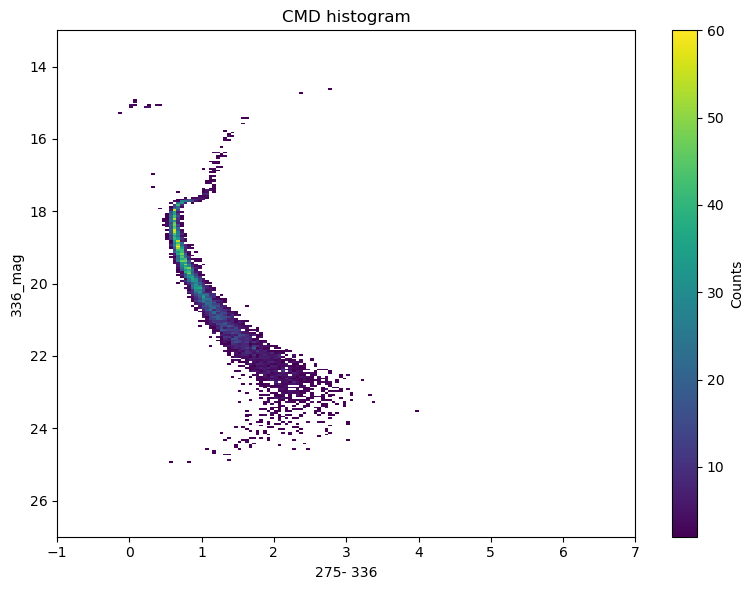

In [9]:
# Filtrating all bins with 0 sources to make them white.
H_masked = np.ma.masked_where(H == 0, H)

plt.figure(figsize=(8, 6))

# Plot using pcolormesh (better for histograms)
plt.pcolormesh(x_edges, y_edges, H_masked.T, shading='auto')

plt.colorbar(label="Counts")

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.title("CMD histogram")
plt.tight_layout()
plt.show()

### 3.3) get_max_width_bins

This is one of the most important steps in the pipeline.

In this stage, the filtered histogram is analyzed row by row (i.e., along each horizontal line) to identify the longest contiguous segment of bins with non-zero counts. These segments represent regions with consistent source density, which are likely part of the main sequence.

To make the method more robust, small gaps of up to 1 bin are allowed within a segment. This prevents minor fluctuations or noise from breaking otherwise continuous structures.

If the longest segment in a given row exceeds the threshold defined by **min_step**, its indices are stored. Otherwise, the row is discarded, and the algorithm proceeds to the next one.

In [10]:
center_line = []
min_edge = []
max_edge = []

for column in H.T:

    indexes = []
    values = []

    stored_idx = []
    stored_val = []

    insured_idx = []
    insured_val = []

    width = 0
    insured_width = 0
    max_width = 0
    empty_count = 0

    for i, val in enumerate(column):

        if val > 0:
            empty_count = 0
            width += 1

            stored_idx.append(i)
            stored_val.append(val)

            insured_idx = []
            insured_val = []
            insured_width = 0

        else:
            empty_count += 1

            if empty_count < 2:
                # Save previous valid segment
                insured_idx = stored_idx.copy()
                insured_val = stored_val.copy()
                insured_width = width

                # Extend segment including gap
                width += 1
                stored_idx.append(i)
                stored_val.append(val)

            else:
                # Evaluate insured segment
                if insured_width > max_width and insured_width >= ms_params.min_step:
                    indexes = insured_idx
                    values = insured_val
                    max_width = insured_width

                # Reset everything
                stored_idx = []
                stored_val = []
                insured_idx = []
                insured_val = []
                width = 0
                insured_width = 0

    # Final assignment
    if len(indexes) > 0:
        min_edge.append(indexes[0])
        max_edge.append(indexes[-1])

        weighted_mean = np.average(indexes, weights=values)
        center_line.append(weighted_mean)
    else:
        min_edge.append(0)
        max_edge.append(0)
        center_line.append(0)

center_line = np.array(center_line)
min_edge = np.array(min_edge)
max_edge = np.array(max_edge)

#### Plotting min, max and center line

The min, max, and center lines represent the left boundary, right boundary, and the weighted central path of the Main Sequence (MS), respectively.

At this stage, these values are expressed in terms of histogram bin indices, not in physical units (e.g., magnitude or color).

Plotting these lines allows us to visually verify how well the algorithm captures the structure of the Main Sequence within the CMD.

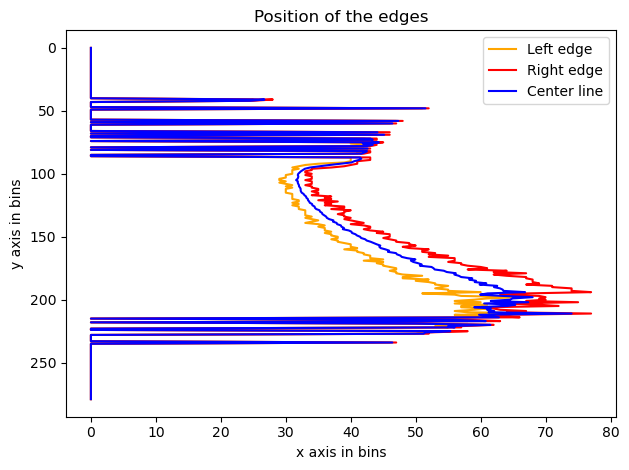

In [11]:
# Plots the found boundaries and center line of the MS, but they are in bin indexes of the np.histogram
plt.plot(min_edge, range(bins[1]), c = "orange", label = "Left edge")
plt.plot(max_edge, range(bins[1]), c = "red", label = "Right edge")
plt.plot(center_line, range(bins[1]), c = "blue", label = "Center line")

plt.xlabel("x axis in bins")
plt.ylabel("y axis in bins")

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.title("Position of the edges")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4) extract_main_sequence

The plot shows several points where the lines abruptly shift to the left. This occurs when, for a given horizontal row, no segment with more than **min_step** bins is found. In these cases, the line is assigned a value of 0, which does not represent meaningful data.

Therefore, these points must be removed. To isolate the Main Sequence, we focus on the longest continuous segment of indices in the center line that does not contain zero values.

The procedure is as follows:

- Identify the indices where the center line has a value of 0.
- Compute the gaps between these indices.
- Select the largest continuous segment without zeros, which corresponds to the Main Sequence.
- Transform the values of the lines from bin indexes to magnitudes.

In [12]:
# --- Find zero positions ---
zero_idx = np.where(center_line == 0)[0]

# Edge case: no zeros → entire range is MS
if len(zero_idx) < 2:
    start = 0
    main_sequence = np.arange(len(center_line))
else:


    # --- Find largest gap between zeros ---
    gaps = zero_idx[1:] - zero_idx[:-1] - 1

    max_gap_idx = np.argmax(gaps)
    max_width = gaps[max_gap_idx]
    start = zero_idx[max_gap_idx]

    main_sequence = np.arange(start + 1, start + max_width)


# --- Extract MS in bin space ---
filtered_center = center_line[main_sequence]
filtered_min = min_edge[main_sequence]
filtered_max = max_edge[main_sequence]


# --- Convert to magnitude space ---
offset = 1 / (2 * bins_division)

normalized_min = filtered_min / bins_division + xmin + offset
normalized_max = filtered_max / bins_division + xmin + offset
normalized_center = filtered_center / bins_division + xmin + offset

main_sequence_y = main_sequence / bins_division  + ymin + offset

MS_index_start = start + 1

#### Plotting Main Sequence

¡We finally found the Main sequence!

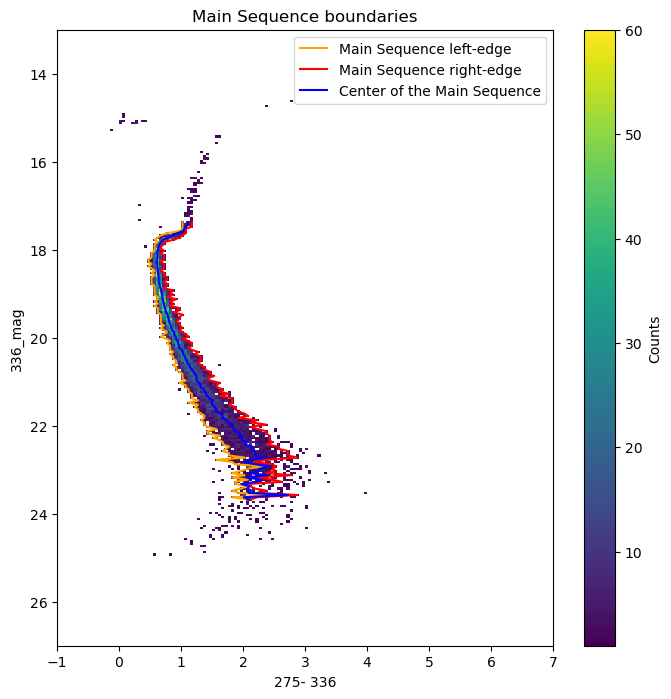

In [13]:
plt.figure(figsize = (8, 8))

#Plotting the boundaries and center line of the Main Sequence
plt.plot(normalized_min, main_sequence_y, c = "orange", label = "Main Sequence left-edge")
plt.plot(normalized_max, main_sequence_y, c = "red", label = "Main Sequence right-edge")
plt.plot(normalized_center, main_sequence_y, c = "blue", label = "Center of the Main Sequence")

cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin will be white

# Plot using pcolormesh (better for histograms)
plt.pcolormesh(
    x_edges, y_edges, H.T,
    cmap=cmap,
    vmin=1  # everything <1 (i.e. 0) becomes white
)

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.title("Main Sequence boundaries")
plt.colorbar(label='Counts')
plt.legend()

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.show()

### 3.5) smooth_sequence

The extracted Main Sequence appears noisy and irregular, with noticeable spikes caused by fluctuations in the histogram. To obtain a more reliable representation, we apply a Savitzky–Golay filter to smooth the data.

The smoothing parameters are chosen carefully:

- The window size is adapted to the length of the sequence to ensure stable smoothing.
- The polynomial order must be smaller than the window size.
- A very low polynomial order can lead to oversmoothing, losing important structure.
- A very high polynomial order may preserve noise, failing to remove spikes.

In practice, a polynomial order of 7 provides a good balance between smoothing the noise and preserving the shape of the Main Sequence.

In [14]:
from scipy.signal import savgol_filter

normalized_min = np.array(normalized_min)
normalized_max = np.array(normalized_max)
normalized_center = np.array(normalized_center)

window = max(5, int(len(normalized_min)/3) | 1) # Window size for Savitzky-Golay filter (must be odd)

poly = min(7, window - 1)

min_smooth = np.array(savgol_filter(normalized_min, window, poly))
max_smooth = np.array(savgol_filter(normalized_max, window, poly))
center_smooth = np.array(savgol_filter(normalized_center, window, poly))

#### Plotting the smoothed boundaries

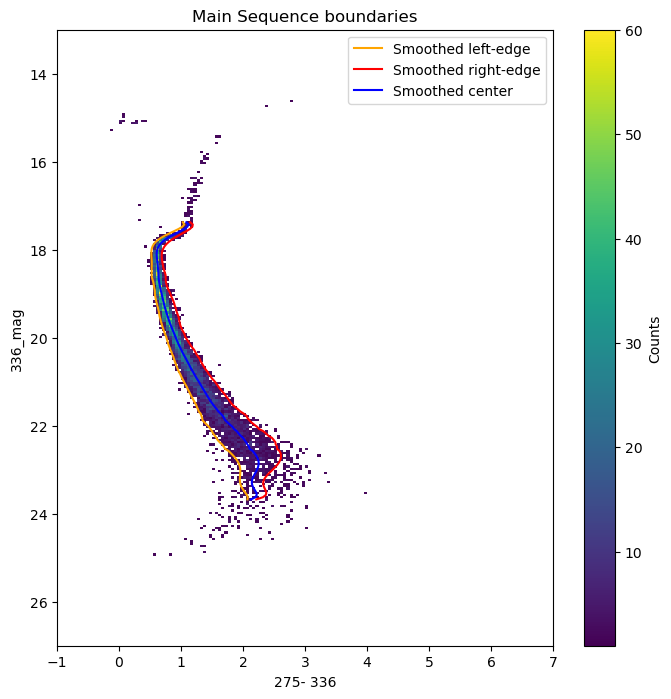

In [15]:
plt.figure(figsize = (8, 8))

# Plotting the smothed boundaries and center line of the main sequence
plt.plot(min_smooth, main_sequence_y, c = "orange", label = "Smoothed left-edge")
plt.plot(max_smooth, main_sequence_y, c = "red", label = "Smoothed right-edge")
plt.plot(center_smooth, main_sequence_y, c = "blue", label = "Smoothed center")

cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin will be white

# Plot using pcolormesh (better for histograms)
plt.pcolormesh(
    x_edges, y_edges, H.T,
    cmap=cmap,
    vmin=1  # everything <1 (i.e. 0) becomes white
)

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.title("Main Sequence boundaries")
plt.colorbar(label='Counts')
plt.legend()

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.show()

### 3.6) detect_msto

To detect the start of the Main Sequence Turn-Off (MSTO), we identify the point where the Main Sequence begins to bend toward the red (i.e., where its slope changes).

This is done using the smoothed center line of the Main Sequence:

- First, we compute the discrete derivative of the smoothed sequence.
- Then, we locate the index where the slope transitions from non-positive to positive, which indicates the turning point.
- Finally we transform the index to magnitude.

This transition marks the MSTO, where the sequence stops decreasing in magnitude and starts to curve.

In [16]:
derivative = np.diff(center_smooth)

negative = np.where(derivative <= 0)[0]


# --- Get the first index where the derivative changes from negative to positive ---
index_MSTO = next((i for i, x in enumerate(np.diff(np.append(negative, negative[-1]))) if x != 1), -1)

offset = 1 / (2 * bins_division)

msto_y = (index_MSTO + MS_index_start) / bins_division + ymin + offset

### 3.7) We limit the length of the MSTO and SGB to avoid misclassifications

The Main Sequence Turn-Off (MSTO) is a relatively small region that smoothly connects to the Subgiant Branch (SGB). However, in practice, the region above the MSTO can extend too far, combining both structures and potentially leading to misclassifications.

To avoid this, we impose a maximum allowed vertical length (in magnitude) for the MSTO+SGB region, controlled by the parameter ***maximum_length_MSTO**.

The procedure is as follows:

- Convert the maximum allowed physical length into the corresponding index range of the histogram.
- Define the start of the SGB as a region located below the MSTO, using a fraction (half) of this allowed length.
- Check whether the MSTO lies too deep within the sequence (i.e., exceeds the allowed length).
- If so, trim the lower part of the sequence, keeping only the portion within the allowed range.
- Adjust the corresponding indices to remain consistent with the trimmed data.
- Finally we get the points G and H that are the left and right boundaries at the start of the MSTO, those will be used later.

This step ensures that the MSTO and SGB region has a controlled and consistent size, preventing overly extended structures from introducing errors in the subsequent classification stages.

In [17]:
# Convert physical height → index space
max_msto_idx = int(ms_params.maximum_lenght_MSTO * bins_division)


# Define SGB start (half of MSTO window below MSTO)
half_window = max_msto_idx // 2
index_SGB = max(0, index_MSTO - half_window)


# If MSTO is too deep in the sequence → trim lower part
if index_MSTO > max_msto_idx:

    shift = index_MSTO - max_msto_idx

    # Trim arrays
    main_sequence_y = main_sequence_y[shift:]
    min_smooth = np.asarray(min_smooth)[shift:]
    max_smooth = np.asarray(max_smooth)[shift:]

    # Adjust indices
    index_MSTO -= shift
    index_SGB -= shift

main_sequence_y = np.asarray(main_sequence_y, dtype=np.float64)
min_smooth = np.asarray(min_smooth, dtype=np.float64)
max_smooth = np.asarray(max_smooth, dtype=np.float64)


# --- Points G and H will be used later. ---
point_G = np.array([max_smooth[index_MSTO], msto_y])
point_H = np.array([min_smooth[index_MSTO], msto_y])


# Creating variables for the resuts
main_sequence_results = MainSequenceResults(main_sequence_y = main_sequence_y,
    min_smooth = min_smooth,
    max_smooth = max_smooth,
    index_SGB = index_SGB,
    index_MSTO = index_MSTO,
    msto_y = msto_y
)
points = Points(point_G = point_G, point_H = point_H)

#### Plotting the MS with the start of the Main Sequence Turn Off (MSTO) and Red Giant Branch RGB

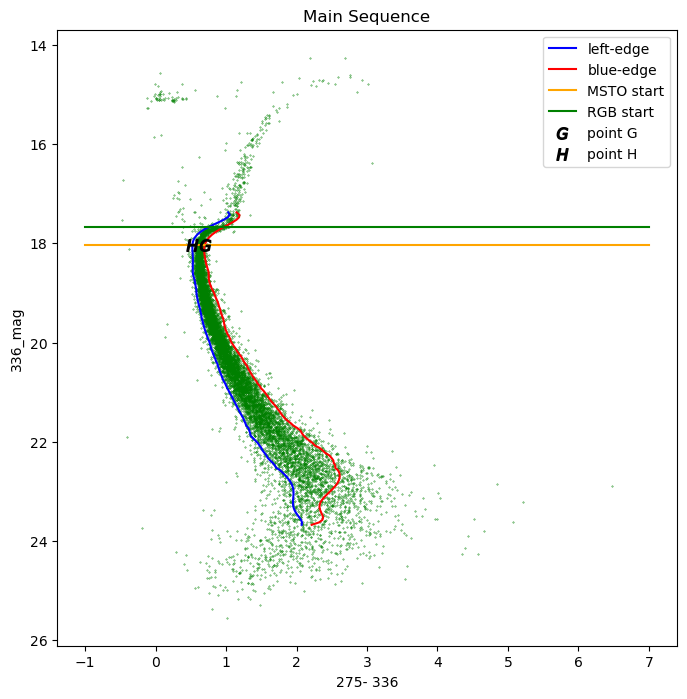

In [18]:
plt.figure(figsize = (8, 8))

# Ploting the boundaries and dividing lines of the MS, MSTO and RGB
plt.plot(min_smooth, main_sequence_y, c = "blue", label = "left-edge")
plt.plot(max_smooth, main_sequence_y, c = "red", label = "blue-edge")
plt.plot(ranges[0], [main_sequence_y[index_MSTO], main_sequence_y[index_MSTO]], c = "orange", label = "MSTO start")
plt.plot(ranges[0], [main_sequence_y[index_SGB], main_sequence_y[index_SGB]], c = "green", label = "RGB start")

# PLotting all sources
plt.scatter(df[f"{Color1} - {Color2}"], df[f"{Color2}_Mag"], c = "green", s = 0.1)

# Point left and right edge of the MSTO (points G and H)
plt.scatter(points.point_G[0], points.point_G[1], color='black', s=70, label='point G', zorder=10, marker = "$G$")
plt.scatter(points.point_H[0], points.point_H[1], color='black', s=70, label='point H', zorder=10, marker = "$H$")

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.title("Main Sequence")
plt.legend()

plt.gca().invert_yaxis()
plt.show()

## Step 4: classify_optical_data
Once the Main Sequence (MS) has been defined in the CMD, we use this information to classify the sources based on their relative positions.

The procedure is as follows:

- First, sources are classified according to their position relative to the Main Sequence. In particular, we identify objects that are bluer and redder than the MS, MSTO and SGB since these populations are key for detecting systems such as Active Binaries (ABs), Cataclysmic Variables (CVs), and Low-Mass X-ray Binaries (LMXBs).
- Next, the CMD is divided into four regions, allowing a more structured and localized analysis of different stellar populations.
- The Horizontal Branch (HB) is identified using the upper-left region of the CMD.
- The Giant Branch (GB) is classified using the upper-right region.

This step leverages the geometry of the CMD to separate and identify different stellar populations in a systematic way.

### 4.1) classify_position_MS
In this step, sources are classified based on their position relative to the Main Sequence (MS).

The procedure is as follows:

- The classification is divided into three regimes: Main Sequence (MS), Main Sequence Turn-Off (MSTO), and Subgiant Branch (SGB), allowing a more precise treatment of each region.
- The double of the mean width of the Main Sequence is used as a reference to distinguish between sources that are slightly redder/bluer and those that are significantly redder/bluer.
- The Sub-Subgiant Branch (S-SGB) region is defined as the area located to the left of the MSTO and SGB.

This classification provides a refined separation of sources around the Main Sequence, which is essential for identifying different stellar populations.

In [19]:
x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{CMD_config}"

df[pos_col] = "Unknown"

x_vals = df[x_col].values
y_vals = df[y_col].values

width_MS = main_sequence_results.max_smooth - main_sequence_results.min_smooth
mean_width_MS = 2 * np.mean(width_MS)


# --- Loop over MS segments ---
for i in range(len(main_sequence_results.main_sequence_y) - 1):

    xmin_1, xmin_2 = main_sequence_results.min_smooth[i], main_sequence_results.min_smooth[i + 1]
    xmax_1, xmax_2 = main_sequence_results.max_smooth[i], main_sequence_results.max_smooth[i + 1]
    y1, y2 = main_sequence_results.main_sequence_y[i], main_sequence_results.main_sequence_y[i + 1]

    slope = (xmin_2 - xmin_1) / (y2 - y1)

    mask = (y_vals >= y1) & (y_vals < y2)

    if not np.any(mask):
        continue

    y_seg = y_vals[mask]
    x_seg = x_vals[mask]


    # --- Interpolate MS boundaries ---
    x_min_real = xmin_1 + (y_seg - y1) * slope
    x_max_real = xmax_1 + (y_seg - y1) * slope


    # --- Define thresholds ---
    conditions = [
        x_seg < x_min_real - mean_width_MS,
        x_seg < x_min_real,
        x_seg < x_max_real,
        x_seg < x_max_real + mean_width_MS,
    ]


    # --- Choose labels depending on region ---
    if i < main_sequence_results.index_SGB:
        labels = [
            "bluer than MS L2",
            "bluer than SGB L1",
            "SGB",
            "S-SGB",
        ]

    elif i < main_sequence_results.index_MSTO:
        labels = [
            "bluer than MS L2",
            "bluer than MSTO L1",
            "MSTO",
            "S-SGB",
        ]

    else:
        labels = [
            "bluer than MS L2",
            "bluer than MS L1",
            "MS",
            "redder than MS L1",
        ]

    result = np.select(conditions, labels, default="redder than MS L2")

    df.loc[mask, pos_col] = result


# --- Below MS ---
df.loc[y_vals > main_sequence_results.main_sequence_y[-1], pos_col] = "below the MS"

#### Graphical representation of all classified sources

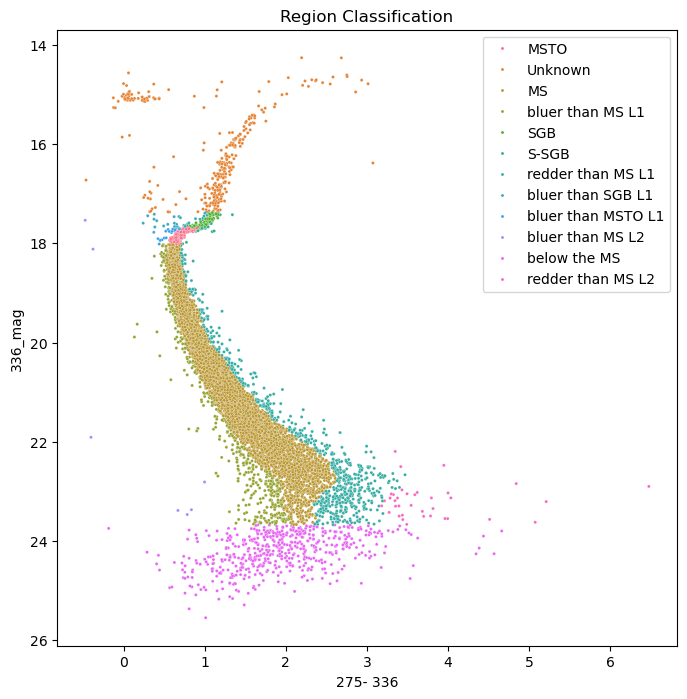

In [20]:
plt.figure(figsize = (8, 8))

# Plotting all classified sources with different colors
sns.scatterplot(data = df, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{CMD_config}", s = 5)
plt.gca().invert_yaxis()


plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")
plt.title("Region Classification")
plt.legend()

plt.show()

### 4.2) create_4_regions
In this step, the optical sources are divided into four regions according to their position relative to the Main Sequence. This separation simplifies the classification process by allowing each region to be analyzed independently.

The regions are defined as follows:

- Region 1: Below the Main Sequence
- Region 2: Between the Main Sequence and the MSTO
- Region 3: Upper-right region (RGB / AGB candidates)
- Region 4: Upper-left region (HB / BS candidates)

To better define the boundary between the upper regions, two reference points are introduced:

Point A: Located at the left boundary near the start of the MSTO
Point B: Located at the left boundary near the end of the RGB

These points help separate Regions 3 and 4 geometrically. However, the classification is not purely geometric. If a source has already been identified as belonging to MSTO or RGB group, they are grouped in the region 3 even if they are in the region 4.

In [21]:
x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{CMD_config}"


# --- Extract arrays ---
x = df[x_col].values
y = df[y_col].values
pos = df[pos_col].values


# --- Key MS points ---
idx_A = np.argmax(main_sequence_results.main_sequence_y == main_sequence_results.msto_y)

point_A = np.zeros(2)
point_B = np.zeros(2)

point_A[0] = main_sequence_results.min_smooth[idx_A]
point_A[1] = main_sequence_results.msto_y

point_B[0] = main_sequence_results.min_smooth[0]
point_B[1] = main_sequence_results.main_sequence_y[0]

y_max_ms = main_sequence_results.main_sequence_y[-1]


# --- Line A → B ---
slope = (point_B[0] - point_A[0]) / (point_B[1] - point_A[1])
x_boundary = point_A[0] + slope * (y - point_A[1])


# --- Masks ---
mask_r1 = y >= y_max_ms

mask_r2 = (y < y_max_ms) & (y >= point_A[1])

mask_upper = (y < point_A[1]) & (y >= point_B[1])
mask_lower = y < point_B[1]

mask_sgb_msto = (pos == "Sub Giant Branch") | (pos == "MSTO")

mask_r3 = (
    (mask_upper & (x > x_boundary)) |
    (mask_lower & (x > point_B[0])) |
    mask_sgb_msto
)

mask_r4 = (
    ((mask_upper & (x <= x_boundary)) |
     (mask_lower & (x <= point_B[0]))) &
    (~mask_sgb_msto)
)


# --- Create regions ---
region1 = df[mask_r1]
region2 = df[mask_r2]
region3 = df[mask_r3]
region4 = df[mask_r4]

points.point_A = point_A
points.point_B = point_B

#### Graphical representation of the four regions

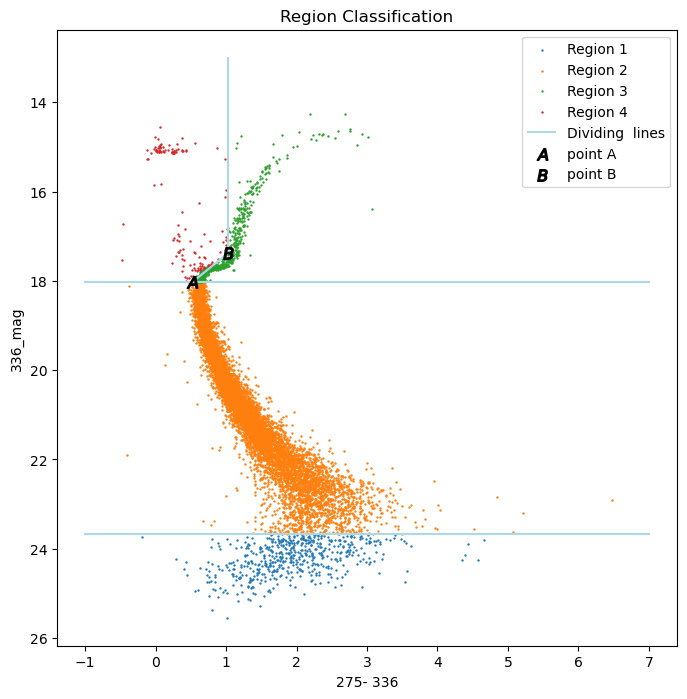

In [22]:
plt.figure(figsize = (8, 8))

# Plotting all 4 regions
plt.scatter(region1[x_col], region1[y_col], s=0.5, label='Region 1')
plt.scatter(region2[x_col], region2[y_col], s=0.5, label='Region 2')
plt.scatter(region3[x_col], region3[y_col], s=0.5, label='Region 3')
plt.scatter(region4[x_col], region4[y_col], s=0.5, label='Region 4')

# Dividing lines
plt.plot([points.point_A[0], points.point_B[0]], [points.point_A[1], points.point_B[1]], c = "lightblue", label = "Dividing  lines")
plt.plot(ranges[0], [points.point_A[1], points.point_A[1]], c = "lightblue")
plt.plot([points.point_B[0], points.point_B[0]], [points.point_B[1], ranges[1][0]], c = "lightblue")
plt.plot(ranges[0], [main_sequence_y[-1], main_sequence_y[-1]], c = "lightblue")

# Points A and B
plt.scatter(points.point_A[0], points.point_A[1], s=70, c = "black", label='point A', zorder=10, marker = "$A$")
plt.scatter(points.point_B[0], points.point_B[1], s=70, c = "black", label='point B', zorder=10, marker = "$B$")

plt.gca().invert_yaxis()

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")
plt.title("Region Classification")
plt.legend()

plt.show()



### 4.3) HB_classification
In this step, Horizontal Branch (HB) stars are identified within Region 4 using a clustering approach.

The procedure is as follows:

- Apply DBSCAN clustering in CMD space to group sources based on their spatial distribution.
- If there are 1 cluster, it is the Horizontal Branch.
- If there are more than 1 cluster, the one in the top left of the region will corresponds to the Horizontal Branch.
- Assign all sources in this cluster to the HB classification.
- Determine and return the bounding points of the HB region:
    - Point C: bottom-left boundary of the HB
    - Point D: top-right boundary of the HB
    - Point E: bottom-right boundary of th HB

This approach allows for a data-driven identification of the HB, capturing its structure without relying on fixed boundaries.


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

eps=0.5
min_samples=15

x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{CMD_config}"

x = np.array(region4[x_col].values)
y = np.array(region4[y_col].values)


# --- Prepare data ---
X = np.column_stack((x, y))
X_scaled = StandardScaler().fit_transform(X)


# --- Clustering ---
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
labels = db.labels_


# --- Get valid clusters (exclude noise) ---
clusters = [l for l in set(labels) if l != -1]

# --- Select cluster ---
if len(clusters) == 1:
    selected_label = clusters[0]
else:
    best_label = None
    best_score = None

    for label in clusters:
        mask = labels == label

        x_mean = np.mean(x[mask])
        y_mean = np.mean(y[mask])

        # TOP-LEFT → minimize x and y
        score = 2 * x_mean + y_mean

        if best_score is None or score < best_score:
            best_score = score
            best_label = label

    selected_label = best_label


# --- Extract selected cluster ---
mask = labels == selected_label

x_sel = x[mask]
y_sel = y[mask]


# --- Define bounding points, they will be used later ---
point_C = np.array([x_sel.min(), y_sel.max()])
point_D = np.array([x_sel.max(), y_sel.min()])
point_E = np.array([x_sel.max(), y_sel.max()])


# --- Assign labels ---
region4.loc[mask, pos_col] = "HB"

points.point_C = point_C
points.point_D = point_D
points.point_E = point_E

### Plotting region 4

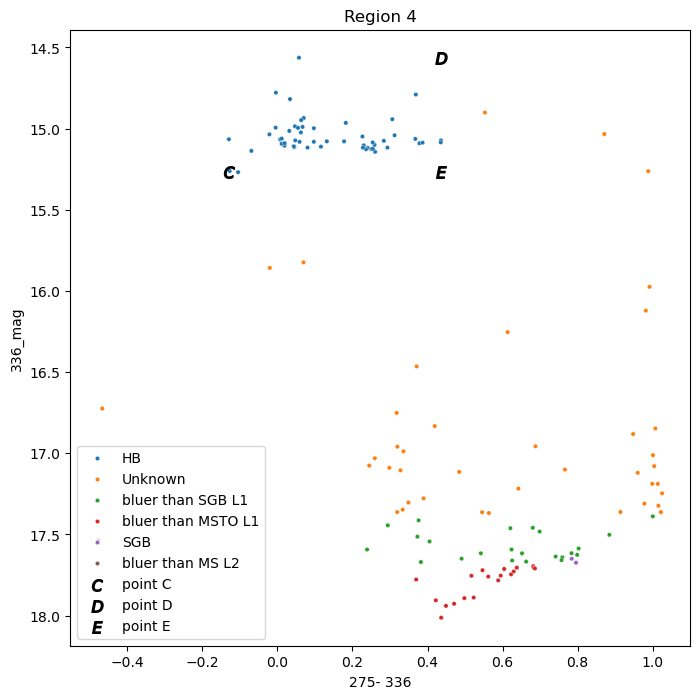

In [24]:
plt.figure(figsize = (8, 8))

# Plotting the classified sources of region 4
sns.scatterplot(data = region4, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{CMD_config}", s = 10)
plt.gca().invert_yaxis()

# Point left and right edge of the MSTO (points I and G)
plt.scatter(points.point_C[0], points.point_C[1], color='black', s=70, label='point C', zorder=10, marker = "$C$")
plt.scatter(points.point_D[0], points.point_D[1], color='black', s=70, label='point D', zorder=10, marker = "$D$")
plt.scatter(points.point_E[0], points.point_E[1], color='black', s=70, label='point E', zorder=10, marker = "$E$")


plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")
plt.title("Region 4")
plt.legend()

plt.show()

### 4.4) RGB_classification
Analize sources of region 3 of the CMD to identify the Red Giant Branch (RGB), Red Stragglers (RS), and Red Super Giant Branch (RSGB).

#### 4.4.1) DBSCAN_classification

First, we apply DBSCAN clustering within Region 3 in CMD space. 
- If there are 1 cluster, it is the Red Giant Branch.
- If multiple clusters are identified, the cluster located in the bottom-left region is selected and labeled as the Red Giant Branch (RGB).
- Next, all sources within this cluster that have not been previously classified are assigned to the RGB category.
- Finally I define the point F as the one at the top right of the Red Giant Branch.

In [25]:
eps = 0.5
min_samples = 15

x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{CMD_config}"

x = np.array(region3[x_col].values)
y = np.array(region3[y_col].values)

# --- DBSCAN clustering ---
X = np.column_stack((x, y))
X_scaled = StandardScaler().fit_transform(X)

labels = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled).labels_
clusters = [l for l in set(labels) if l != -1]

# --- Select RGB cluster (bottom-right) ---
if len(clusters) == 1:
    selected = clusters[0]
else:
    best_label = None
    best_score = None

    for label in clusters:
        mask = labels == label
        x_mean = np.mean(x[mask])
        y_mean = np.mean(y[mask])

        # bottom-right → large x, large y
        score = x_mean - y_mean

        if best_score is None or score < best_score:
            best_score = score
            best_label = label

    selected = best_label

mask_rgb = labels == selected

x_sel = x[mask_rgb]
y_sel = y[mask_rgb]

# --- Key point F ---
point_F = np.array([x_sel.max(), y_sel.min()])

# --- Assign RGB ---
region3.loc[mask_rgb & (region3[pos_col] == "Unknown"), pos_col] = "RGB"
points.point_F = point_F

#### Plotting region 3

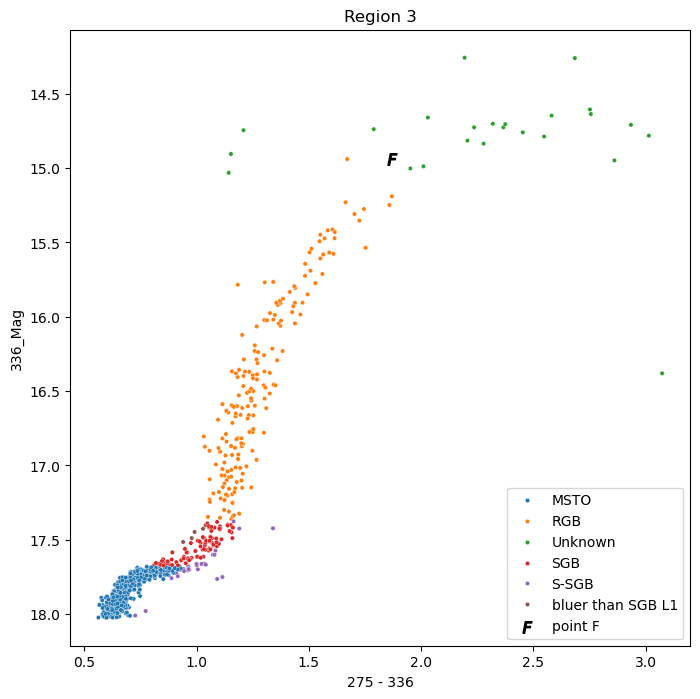

In [26]:
plt.figure(figsize = (8, 8))

# Plotting the Region 3
sns.scatterplot(data = region3, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{CMD_config}", s = 10)

# Plotting the point F at the top right of the RGB
plt.scatter(point_F[0], point_F[1], color='black', s=70, label='point F', zorder=10, marker = "$F$")

plt.gca().invert_yaxis()
plt.legend()
plt.title("Region 3")
plt.show()

#### 4.4.2) ridge_line_extraction

Before performing the classification, it is necessary to define what lies above and below the Red Giant Branch (RGB).

A 2D histogram is constructed, and the ridge line is defined by selecting, for each vertical bin, the position with the highest source density. This traces the central path of the Red Giant Branch (RGB).

The ridge line is then extended to span the full relevant range of the diagram, from the bottom-left boundary of the histogram up to point F, providing a consistent reference for subsequent classification.or all the bins with more sources in every vertical line, the rige line is also extended from the bottom-left boundary of the histogram up to point F.

In [27]:
# --- Histogram for ridge ---
xmin, xmax = x_sel.min(), x_sel.max()
ymin, ymax = y_sel.min(), y_sel.max()

bins = [
    int(bins_division * (xmax - xmin) / 4),
    int(bins_division * (ymax - ymin) / 4)
]

H, xedges, yedges = np.histogram2d(x_sel, y_sel, bins=bins)

x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])

H = H.T
# --- Ridge extraction ---
ridge_x = []
ridge_y = []

for i in range(len(x_centers)):
    column = H[:, i]
    if column.sum() == 0:
        continue

    idx = np.argmax(column)
    ridge_x.append(x_centers[i])
    ridge_y.append(y_centers[idx])

ridge_x = np.array(ridge_x)
ridge_y = np.array(ridge_y)


# --- Extend ridge ---
ridge_x_full = np.concatenate(([xmin], ridge_x, [points.point_F[0]]))
ridge_y_full = np.concatenate(([msto_y], ridge_y, [points.point_F[1]]))

#### Plotting Ridge line

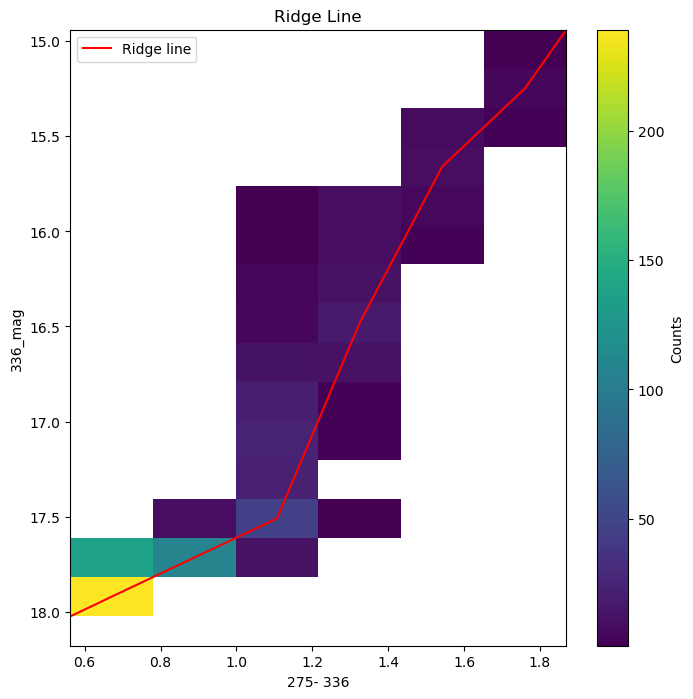

In [28]:
plt.figure(figsize = (8, 8))

cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin will be white

# Plot using pcolormesh (better for histograms)
plt.pcolormesh(
    xedges, yedges, H,
    cmap=cmap,
    vmin=1  # everything <1 (i.e. 0) becomes white
)

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.title("Ridge Line")
plt.colorbar(label='Counts')

# Plotting the point F at the top right of the RGB
plt.plot(ridge_x_full, ridge_y_full, color = "red", label = "Ridge line")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

#### 4.4.3) RSGB_RS_classification

Finally, the remaining unclassified sources are assigned based on their position relative to point F and the RGB ridge line:

- Red Super Giant Branch (RSGB): sources located to the right of point F that have not been previously classified.
- Red Stragglers (RS): sources located to the left of point F and below the RGB ridge line, which also remain unclassified.

In [29]:
from scipy.interpolate import interp1d

y_col= f"{Color2}_Mag"
x_col = f"{Color1} - {Color2}"

x = region3[x_col].values
y = region3[y_col].values
pos_col = f"position_{CMD_config}"


# --- Interpolation ---
ridge_func = interp1d(
    ridge_x_full,
    ridge_y_full,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate" # type: ignore
)

# --- Vectorized classification ---
y_ridge = ridge_func(x)


# --- Classify Red Super Giant Branch (RSGB) sourecs as the ones at the right of the point F ---
mask_super = x > points.point_F[0] 


# --- Classify the sources below the ridge line as Red Stragglers (RS) (Remember that the y axis is inverted)---
mask_straggler = (x <= points.point_F[0]) & (y > y_ridge)


# Apply only where still Unknown
unknown_mask = region3[pos_col] == "Unknown"

region3.loc[unknown_mask & mask_super, pos_col] = "RSGB"
region3.loc[unknown_mask & mask_straggler, pos_col] = "RS"

### Plotting region 3

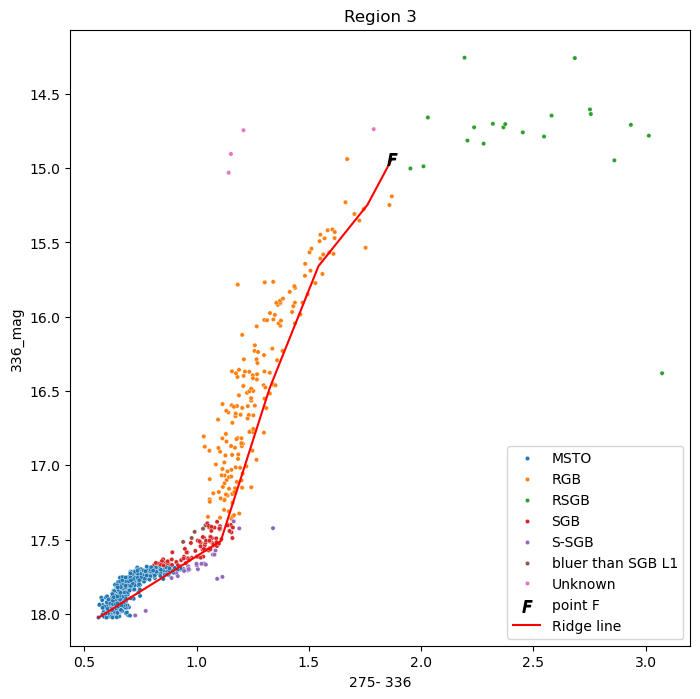

In [30]:
plt.figure(figsize = (8, 8))

# Plotting the Region 3
sns.scatterplot(data = region3, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{CMD_config}", s = 10)

# Plotting the point F at the top right of the RGB
plt.scatter(points.point_F[0], points.point_F[1], color='black', s=70, label='point F', zorder=10, marker = "$F$")

plt.plot(ridge_x_full, ridge_y_full, color = "red", label = "Ridge line")

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.gca().invert_yaxis()
plt.legend()
plt.title("Region 3")
plt.show()

### 4.5) Merging all 4 regions

The classification of each region is done, now we merge them in one DataFrame

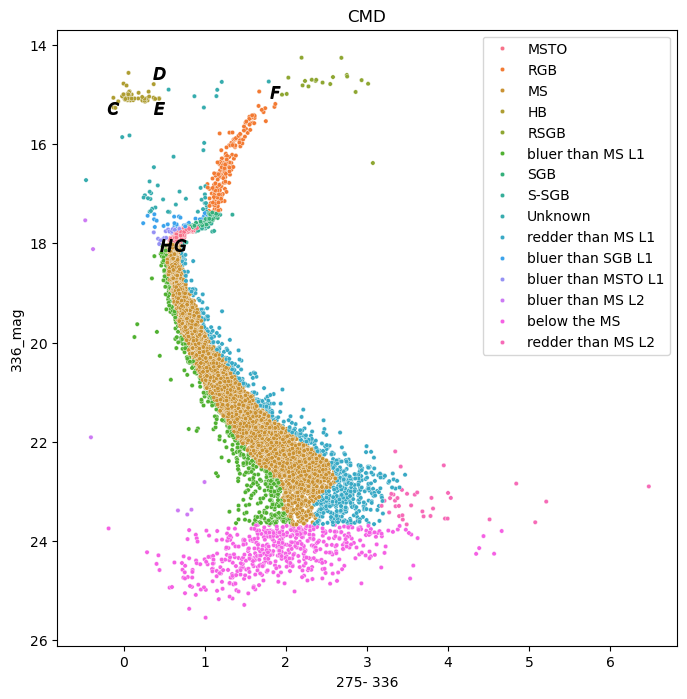

In [31]:
df_merged = pd.concat([region1, region2, region3, region4]).sort_index()

plt.figure(figsize = (8, 8))

# Plotting the 
sns.scatterplot(data = df_merged, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{CMD_config}", s = 10)

# Plotting all important points
plt.scatter(points.point_C[0], points.point_C[1], color='black', s=70, zorder=10, marker = "$C$")
plt.scatter(points.point_D[0], points.point_D[1], color='black', s=70, zorder=10, marker = "$D$")
plt.scatter(points.point_E[0], points.point_E[1], color='black', s=70, zorder=10, marker = "$E$")
plt.scatter(points.point_F[0], points.point_F[1], color='black', s=70, zorder=10, marker = "$F$")
plt.scatter(points.point_G[0], points.point_G[1], color='black', s=70, zorder=10, marker = "$G$")
plt.scatter(points.point_H[0], points.point_H[1], color='black', s=70, zorder=10, marker = "$H$")

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.gca().invert_yaxis()
plt.legend()
plt.title("CMD")
plt.show()

### 4.6) AGB_BS_classification
Finally, the last two populations—Asymptotic Giant Branch (AGB) and Blue Stragglers (BS)—are classified. Since their identification depends on the geometry and boundaries defined by the previously identified groups, this step is performed at the end.

- Blue Stragglers (BS): These stars occupy the intermediate region between the Main Sequence and the Horizontal Branch. All previously unclassified sources located within the polygon defined by points C–D–G–H are assigned to the BS category.
- Asymptotic Giant Branch (AGB): This population lies between the Horizontal Branch and the upper end of the Red Giant Branch. All previously unclassified sources located above the line E–F and to the right of point E are classified as AGB.

In [32]:
from matplotlib.path import Path

x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{CMD_config}"

x = np.array(df_merged[x_col].values)
y = np.array(df_merged[y_col].values)
pos = np.array(df_merged[pos_col].values)


# --- Blue Stragglers ---
polygon = np.array([points.point_C, points.point_D, points.point_G, points.point_H])
poly_path = Path(polygon)

points_polygon = np.column_stack((x, y))
inside = poly_path.contains_points(points_polygon)

mask_bs = (pos == "Unknown") & inside
df_merged.loc[mask_bs, pos_col] = "BS"


# --- AGB ---

# Line point_E → point_F: y = m*x + b
m = (points.point_F[1] - points.point_E[1]) / (points.point_F[0] - points.point_E[0])
b = points.point_E[1] - m * points.point_E[0]

y_line = m * x + b

mask_agb = (
    (pos == "Unknown") &
    (x > points.point_E[0]) &
    (y < y_line)
)

df_merged.loc[mask_agb, pos_col] = "AGB"

# Plotting the complete CMD

Now that all stellar populations have been defined in the CMD, we visualize the final classification.

Each source is plotted according to its assigned class, and the geometric boundaries used in the last step are overlaid for reference. In particular, we include the polygon C–D–G–H and the line E–F, which were used to identify the Blue Stragglers (BS) and Asymptotic Giant Branch (AGB) populations.

This final plot provides a comprehensive view of the classification and helps verify the consistency of the defined regions.

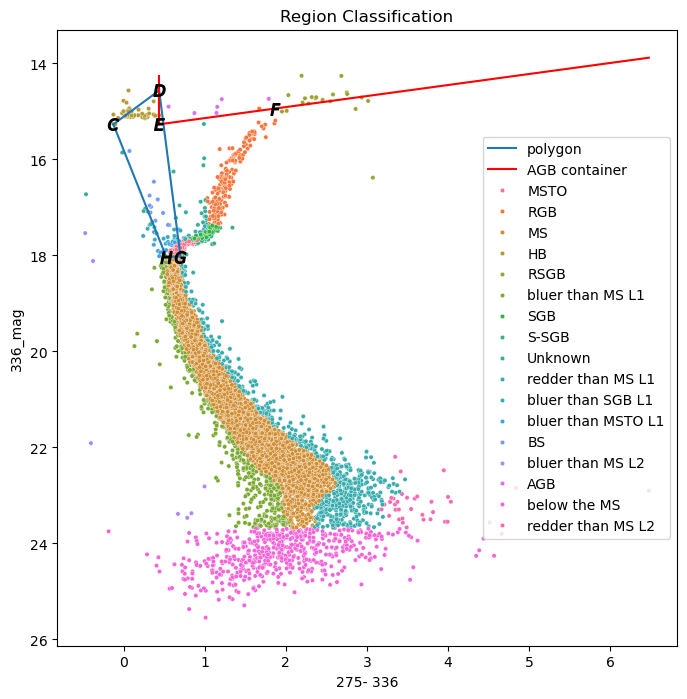

In [33]:
plt.figure(figsize = (8, 8))

# Clossing and plotting the polygon CDGH
polygon = np.append(polygon, np.array([[points.point_C[0], points.point_C[1]]]), axis = 0)
plt.plot(polygon[:,0], polygon[:,1], label = "polygon")

# Line EF
x_plot = np.linspace(points.point_E[0], x.max(), 200)
y_plot = m * x_plot + b
plt.plot([points.point_E[0], points.point_E[0]], [points.point_E[1], y.min()], color='red', label = "AGB container")

# Vertical line in E
plt.plot(x_plot, y_plot, color='red')

# All sources
sns.scatterplot(data = df_merged, x = f"{Color1} - {Color2}", y = f"{Color2}_Mag", hue = f"position_{CMD_config}", s = 10)

# Plotting all important points
plt.scatter(points.point_C[0], points.point_C[1], color='black', s=70, zorder=10, marker = "$C$")
plt.scatter(points.point_D[0], points.point_D[1], color='black', s=70, zorder=10, marker = "$D$")
plt.scatter(points.point_E[0], points.point_E[1], color='black', s=70, zorder=10, marker = "$E$")
plt.scatter(points.point_F[0], points.point_F[1], color='black', s=70, zorder=10, marker = "$F$")
plt.scatter(points.point_G[0], points.point_G[1], color='black', s=70, zorder=10, marker = "$G$")
plt.scatter(points.point_H[0], points.point_H[1], color='black', s=70, zorder=10, marker = "$H$")

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")
plt.gca().invert_yaxis()

plt.title("Region Classification")
plt.legend()


plt.show()